In [1]:
%matplotlib widget
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from ipywidgets import interact, Dropdown, FloatSlider

from parcellation_boundaries.load_freesurfer_data import load_hemisphere, Atlas
from parcellation_boundaries.boundary import build_mesh_cached
from parcellation_boundaries import simplify as S
from parcellation_boundaries import evaluate
from parcellation_boundaries import validate



def _polygon_patch(polygon, **kwargs):
    def ring_codes(n):
        codes = np.ones(n, dtype=MplPath.code_type) * MplPath.LINETO
        codes[0]  = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        return codes
    rings = [np.asarray(polygon.exterior.coords)] + \
            [np.asarray(r.coords) for r in polygon.interiors]
    verts = np.concatenate(rings)
    codes = np.concatenate([ring_codes(len(r)) for r in rings])
    return PathPatch(MplPath(verts, codes), **kwargs)

In [2]:
mesh, data = build_mesh_cached(Atlas.DESTRIEUX, 'lh')
color_by_name = {name: r['color'] for name, r in data.items()}
print(f'Half-edges      : {len(mesh.half_edges)}')
print(f'Face components : {len(mesh.faces)}')
print(f'Regions         : {len(mesh.regions)}')

Half-edges      : 570
Face components : 97
Regions         : 75


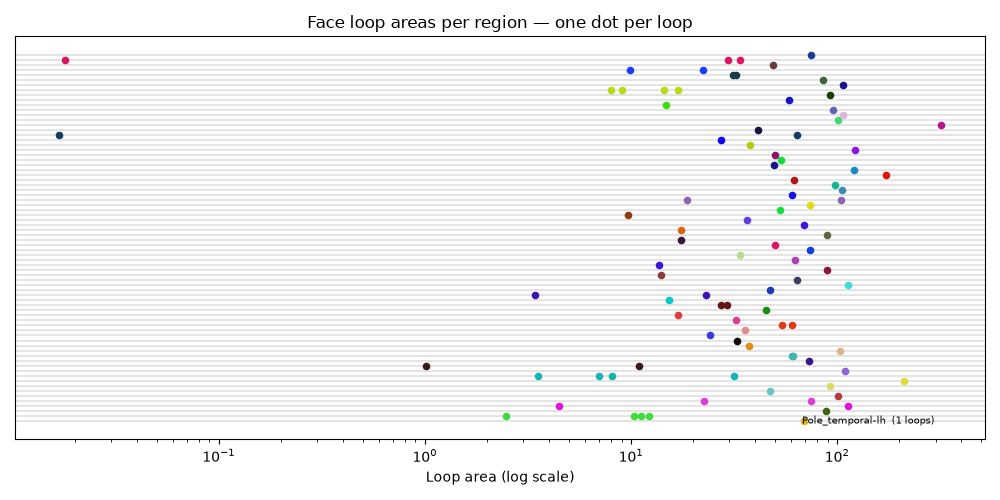

In [3]:
# ── Loop area distribution per region ─────────────────────────────────────────
# Diagnose the multiple-loop issue: are the extra loops tiny disconnected fragments?
from shapely.geometry import Polygon as _Poly

fig_d, ax_d = plt.subplots(figsize=(10, 5))

region_names_plot = [n for n in mesh.regions if n != '__hull__']
for yi, name in enumerate(region_names_plot):
    loops = mesh.face_loop_coords(name)
    areas = [abs(_Poly(loop).area) for loop in loops if len(loop) >= 4]
    col   = color_by_name.get(name, (0.5, 0.5, 0.5))
    ax_d.scatter(areas, [yi] * len(areas), color=col, s=20, zorder=3)
    ax_d.axhline(yi, color='grey', linewidth=0.3, zorder=1)
    ax_d.text(ax_d.get_xlim()[0], yi, f' {name}  ({len(areas)} loops)',
              va='center', fontsize=7)

ax_d.set_xscale('log')
ax_d.set_xlabel('Loop area (log scale)')
ax_d.set_yticks([])
ax_d.set_title('Face loop areas per region — one dot per loop')
fig_d.tight_layout()
plt.show()

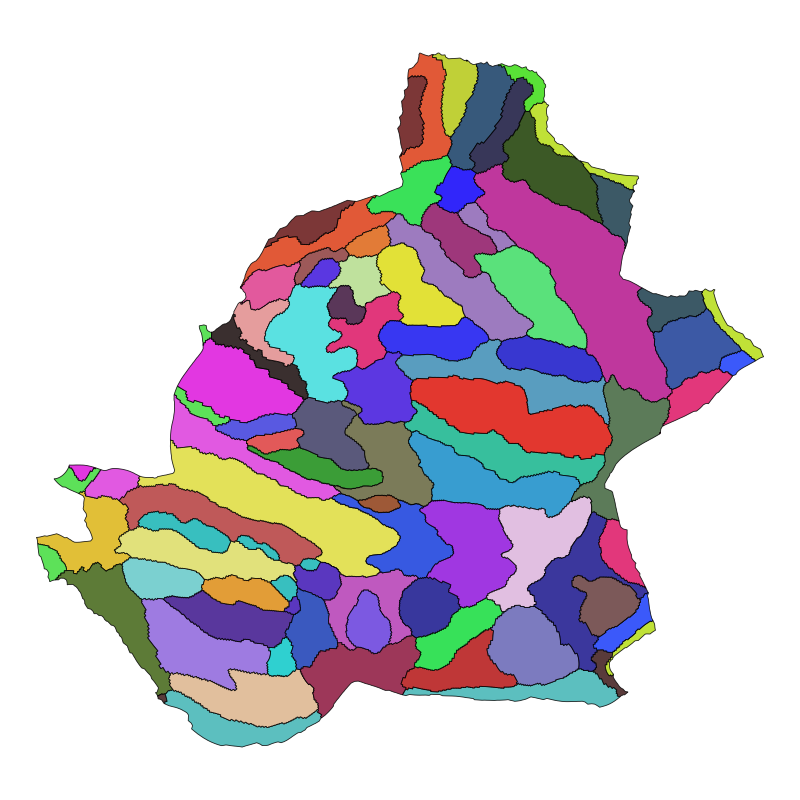

In [4]:
# Draw unsimplified mesh (run after the interactive cell to share _polygon_patch)
shapes = mesh.to_shapes()

fig0, ax0 = plt.subplots(figsize=(8, 8))
for name, geom in shapes.items():
    col   = color_by_name.get(name, (0.6, 0.6, 0.6))
    polys = geom.geoms if hasattr(geom, 'geoms') else [geom]
    for poly in polys:
        if poly.geom_type == 'Polygon' and not poly.is_empty:
            ax0.add_patch(_polygon_patch(poly, fc=col, ec='black', linewidth=0.6, alpha=0.85))

ax0.autoscale_view()
ax0.set_aspect('equal')
ax0.axis('off')
fig0.tight_layout(pad=0)
plt.show()

In [7]:
import ipywidgets as widgets
from IPython.display import display
from shapely.geometry import Point, Polygon
from shapely.strtree import STRtree
from shapely.ops import unary_union

ALGORITHMS = {
    'none':               None,
    'Douglas-Peucker':    S.dp,
    'Visvalingam-Whyatt': S.vw,
    'Saalfeld':           'saalfeld',
    'TopoVW (modified)':  'topovw_modified',
    'TopoVW':             'topovw',
    'de Berg':            'deberg',
}

_state = {
    'lh': {'atlas': None, 'mesh': None, 'orig': None,
           'color_by': {}, 'pts': None, 'labels': None, 'face_seeds': None},
    'rh': {'atlas': None, 'mesh': None, 'orig': None,
           'color_by': {}, 'pts': None, 'labels': None, 'face_seeds': None},
    'simp_names':  [],
    'simp_geoms':  [],
    'simp_tree':   None,
    '_last_hover': None,
}

atlas_w = widgets.Dropdown(
    options=[a.name for a in Atlas], value='DESTRIEUX',
    description='Atlas', style={'description_width': 'initial'})
hemi_w  = widgets.Dropdown(
    options=['lh', 'rh', 'both'], value='both',
    description='Hemi', style={'description_width': 'initial'})
algo_w  = widgets.Dropdown(
    options=list(ALGORITHMS.keys()), value='none',
    description='Algorithm', style={'description_width': 'initial'})
eps_w   = widgets.FloatSlider(
    value=1.0, min=0.01, max=20.0, step=0.05,
    continuous_update=False, description='ε')

fig_out     = widgets.Output()
metrics_out = widgets.Output()

_ann_kw = dict(xycoords='data', xytext=(10, 10), textcoords='offset points',
               bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#555', alpha=0.88),
               fontsize=8, visible=False, zorder=10)

with fig_out:
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(10, 5))
    fig.tight_layout(pad=0)
    _anns = {
        ax_l: ax_l.annotate('', xy=(0, 0), **_ann_kw),
        ax_r: ax_r.annotate('', xy=(0, 0), **_ann_kw),
    }
    plt.show()

_hover_cid = [None]


def _mesh_arcs(mesh):
    """Split a mesh's arcs into (inner_arcs, outer_arcs) coord lists."""
    seen = set()
    inner, outer = [], []
    fr = mesh.face_region
    for h in mesh.half_edges:
        if id(h.arc) in seen:
            continue
        seen.add(id(h.arc))
        is_hull = fr[h.face] == '__hull__' or fr[h.twin.face] == '__hull__'
        (outer if is_hull else inner).append(h.arc.coords)
    return inner, outer


def _gap_fraction(shapes):
    union = unary_union(list(shapes.values()))
    if union.is_empty:
        return 0.0
    hull = (Polygon(union.exterior) if union.geom_type == 'Polygon'
            else Polygon(max(union.geoms, key=lambda g: g.area).exterior))
    return hull.difference(union).area / hull.area if hull.area > 0 else 0.0


def _load_hemi(atlas_name, hemi):
    s = _state[hemi]
    if s['atlas'] != atlas_name:
        m, d = build_mesh_cached(Atlas[atlas_name], hemi, min_area=0, min_points=1)
        s['atlas']      = atlas_name
        s['mesh']       = m
        s['orig']       = m.to_shapes()
        s['color_by']   = {n: r['color'] for n, r in d.items()}
        s['pts']        = np.column_stack([
            np.concatenate([r['x'] for r in d.values()]),
            np.concatenate([r['y'] for r in d.values()]),
        ])
        s['face_seeds'] = {n: np.column_stack([r['x'], r['y']]) for n, r in d.items()}
        s['labels']     = np.concatenate([
            np.full(len(r['x']), n, dtype=object) for n, r in d.items()
        ])
    return s


def _simplify_mesh(s, algorithm, epsilon):
    """Return the simplified HalfEdgeMesh (before to_shapes)."""
    mesh = s['mesh']
    fn   = ALGORITHMS[algorithm]
    if fn is None:
        return mesh
    if fn == 'saalfeld':
        return S.simplify_saalfeld(mesh, epsilon)
    if fn == 'topovw_modified':
        return S.simplify_topovw_modified(mesh, epsilon, face_seeds=s['face_seeds'])
    if fn == 'topovw':
        n_remove = max(0, int(round(epsilon * S.count_interior_points(mesh))))
        return S.simplify_topovw(mesh, n_remove)
    if fn == 'deberg':
        return S.simplify_deberg(mesh, epsilon)
    return S.simplify(mesh, epsilon, fn)


def _draw_shapes(ax, shapes, color_by):
    for name, geom in shapes.items():
        col   = color_by.get(name, (0.6, 0.6, 0.6))
        polys = geom.geoms if hasattr(geom, 'geoms') else [geom]
        for poly in polys:
            if poly.geom_type == 'Polygon' and not poly.is_empty:
                ax.add_patch(_polygon_patch(poly, fc=col, ec='black',
                                            linewidth=0.6, alpha=0.85))
    ax.autoscale_view()
    ax.set_aspect('equal')
    ax.axis('off')


def _print_metrics(orig, orig_mesh, simp, simp_mesh, pts, labels, hemi_label):
    W  = 26
    total_area = sum(s.area for s in orig.values())
    gf  = _gap_fraction(simp)
    vc  = evaluate.vertex_count(simp)['total']
    vr  = evaluate.vertex_retention(orig, simp)
    iou = evaluate.iou(orig, simp)
    rae = evaluate.relative_area_error(orig, simp)
    hd  = evaluate.hausdorff(orig, simp)
    hd1 = evaluate.hausdorff_one_sided(orig, simp)
    pc  = evaluate.pixel_comparison(orig, simp)
    la  = evaluate.label_accuracy(simp, pts, labels)

    print(f'\n  ── {hemi_label} {"─"*(W+18)}')
    print(f'  {"total parcellation area":<{W}} {total_area:>8.1f}')
    print(f'  {"vertices":<{W}} {vc:>8,}   retention {vr:.1%}')
    print(f'  {"gap fraction":<{W}} {gf:>8.2e}  {"⚠  GAP" if gf > 1e-6 else "ok"}')
    print(f'  {"IoU":<{W}} mean {iou["mean"]:.4f}   min {iou["min"]:.4f}')
    print(f'  {"area error":<{W}} mean {rae["mean"]:.4f}   max {rae["max"]:.4f}')
    print(f'  {"Hausdorff (sym)":<{W}} mean {hd["mean"]:.4f}   max {hd["max"]:.4f}')
    print(f'  {"Hausdorff (1-sided)":<{W}} mean {hd1["mean"]:.4f}   max {hd1["max"]:.4f}')
    print(f'  {"pixel comparison":<{W}} {pc["accuracy"]:.4f}   '
          f'({pc["pixels_compared"]:,} px at {pc["resolution"][0]}×{pc["resolution"][1]})')
    print(f'  {"label accuracy":<{W}} {la["accuracy"]:.4f}   '
          f'({la["correct"]:,} / {la["total"]:,} pts)')

    orig_inner, orig_outer = _mesh_arcs(orig_mesh)
    simp_inner, simp_outer = _mesh_arcs(simp_mesh)

    checks = {
        'completeness':    validate.check_completeness(orig, simp),
        'validity':        validate.check_validity(simp),
        'component_count': validate.check_component_count(orig, simp),
        'no_overlap':      validate.check_no_overlap(simp),
        'adjacency_graph': validate.check_adjacency_graph(orig, simp),
        'junction_count':  validate.check_junction_count(
                               orig_inner + orig_outer, simp_inner + simp_outer),
        'no_gaps':         validate.check_no_gaps(simp, simp_outer),
        'no_crossings':    validate.check_no_crossings(simp_inner, simp_outer),
    }
    print(f'  {"─"*(W+22)}')
    for cname, r in checks.items():
        status = 'PASS' if r['passed'] else 'FAIL'
        detail = ''
        if not r['passed']:
            if r.get('overlapping_pairs'):
                pairs = r['overlapping_pairs'][:3]
                detail = (f'{len(r["overlapping_pairs"])} pairs — '
                          + ', '.join(f'{a}&{b} ({area:.2g})' for a, b, area in pairs))
            elif r.get('lost_edges') or r.get('gained_edges'):
                lost   = r.get('lost_edges', [])
                gained = r.get('gained_edges', [])
                detail  = (f'lost {len(lost)}: {lost[:2]}  ' if lost else '')
                detail += (f'gained {len(gained)}: {gained[:2]}' if gained else '')
            elif r.get('changed'):
                parts = []
                for n, v in list(r['changed'].items())[:4]:
                    part = f'{n}: {v["original"]}→{v["simplified"]}'
                    removed = r.get('removed_components', {}).get(n, [])
                    if removed:
                        locs = ', '.join(f'({cx:.1f},{cy:.1f}) a={a:.2g}'
                                         for (cx, cy), a in removed[:2])
                        part += f' [{locs}]'
                    parts.append(part)
                detail = '  '.join(parts)
            elif r.get('invalid'):
                detail = ', '.join(r['invalid'][:4])
            elif r.get('missing'):
                detail = 'missing: ' + ', '.join(r['missing'][:3])
            elif r.get('extra'):
                detail = 'extra: ' + ', '.join(r['extra'][:3])
            elif cname == 'junction_count':
                detail = f'original {r["original"]}  simplified {r["simplified"]}'
            elif cname == 'no_gaps':
                detail = f'gap_fraction={r["gap_fraction"]:.2e}'
            elif r.get('crossings'):
                detail = f'{len(r["crossings"])} crossing(s)'
        print(f'  {status}  {cname:<{W}} {detail}')


def on_hover(event):
    if event.inaxes not in _anns or event.xdata is None:
        for ann in _anns.values():
            if ann.get_visible():
                ann.set_visible(False)
                fig.canvas.draw_idle()
        return
    tree  = _state['simp_tree']
    names = _state['simp_names']
    geoms = _state['simp_geoms']
    if tree is None:
        return
    pt  = Point(event.xdata, event.ydata)
    hit = None
    for idx in tree.query(pt):
        if geoms[idx].contains(pt):
            hit = names[idx]
            break
    if hit == _state['_last_hover']:
        return
    _state['_last_hover'] = hit
    cur_ann = _anns[event.inaxes]
    for ann in _anns.values():
        ann.set_visible(False)
    if hit:
        cur_ann.set_text(hit)
        cur_ann.xy = (event.xdata, event.ydata)
        cur_ann.set_visible(True)
    fig.canvas.draw_idle()


if _hover_cid[0] is not None:
    fig.canvas.mpl_disconnect(_hover_cid[0])
_hover_cid[0] = fig.canvas.mpl_connect('motion_notify_event', on_hover)


def draw(atlas_name='DESTRIEUX', hemi='lh', algorithm='none', epsilon=1.0):
    hemis = ['lh', 'rh'] if hemi == 'both' else [hemi]
    for h in hemis:
        _load_hemi(atlas_name, h)

    simp_mesh  = {h: _simplify_mesh(_state[h], algorithm, epsilon) for h in hemis}
    simp_shape = {h: simp_mesh[h].to_shapes() for h in hemis}

    # Hover index spans all visible shapes
    all_simp = {}
    for h in hemis:
        all_simp.update(simp_shape[h])
    _state['simp_names']  = list(all_simp.keys())
    _state['simp_geoms']  = [all_simp[n] for n in _state['simp_names']]
    _state['simp_tree']   = STRtree(_state['simp_geoms'])
    _state['_last_hover'] = None
    for ann in _anns.values():
        ann.set_visible(False)

    # Layout: both → two panels; single → left fills, right hidden
    if hemi == 'both':
        ax_l.set_position([0.01, 0.02, 0.49, 0.96])
        ax_r.set_position([0.51, 0.02, 0.49, 0.96])
        ax_r.set_visible(True)
    else:
        ax_l.set_position([0.01, 0.02, 0.98, 0.96])
        ax_r.set_visible(False)

    ax_l.cla()
    ax_l.add_artist(_anns[ax_l])
    _draw_shapes(ax_l, simp_shape[hemis[0]], _state[hemis[0]]['color_by'])
    vc_l = evaluate.vertex_count(simp_shape[hemis[0]])['total']
    ax_l.set_title(f'{atlas_name} {hemis[0]}  {algorithm}  ε={epsilon:.3g}  v={vc_l:,}',
                   fontsize=9)

    if hemi == 'both':
        ax_r.cla()
        ax_r.add_artist(_anns[ax_r])
        _draw_shapes(ax_r, simp_shape['rh'], _state['rh']['color_by'])
        vc_r = evaluate.vertex_count(simp_shape['rh'])['total']
        ax_r.set_title(f'{atlas_name} rh  {algorithm}  ε={epsilon:.3g}  v={vc_r:,}',
                       fontsize=9)

    fig.canvas.draw_idle()

    metrics_out.clear_output(wait=True)
    with metrics_out:
        for h in hemis:
            _print_metrics(
                _state[h]['orig'], _state[h]['mesh'],
                simp_shape[h], simp_mesh[h],
                _state[h]['pts'], _state[h]['labels'], h)


_ = widgets.interactive_output(draw, {
    'atlas_name': atlas_w,
    'hemi':       hemi_w,
    'algorithm':  algo_w,
    'epsilon':    eps_w,
})

display(widgets.VBox([
    widgets.HBox([atlas_w, hemi_w, algo_w, eps_w]),
    fig_out,
    metrics_out,
]))

In [6]:
# Sanity checks
errors = []
for h in mesh.half_edges:
    if h.next is None:
        errors.append(f'next=None on face {h.face}')
    elif h.next.prev is not h:
        errors.append(f'next/prev mismatch on face {h.face}')
    if h.twin is None:
        errors.append(f'twin=None on face {h.face}')
    elif h.twin.twin is not h:
        errors.append(f'twin/twin mismatch on face {h.face}')
    elif h.twin.face == h.face:
        errors.append(f'twin has same face: {h.face} ({mesh.face_region[h.face]})')

if errors:
    for e in errors[:20]:
        print('ERROR:', e)
else:
    print('All half-edge invariants OK')

# Check face loops are closed (start coord == end coord)
for name in mesh.regions:
    for loop in mesh.face_loop_coords(name):
        if not np.allclose(loop[0], loop[-1]):
            print(f'OPEN LOOP in region {name}')
print('Loop closure check done')

All half-edge invariants OK
Loop closure check done
